# `m_z` forced-acceleration CFD 后处理

这个 notebook 用于从 STAR-CCM+ 控制台解析结果中计算 heave 方向的平动惯性参数。

目标输出：

1. 读取清洗后的 `Fz_PhysicalTime.csv` 数据；
2. 提取 $F_{z,0}$ 和 $F_{z,3}$；
3. 按 Javanmard procedure two 计算正的 added-mass scalar $-Z_{\dot w}$；
4. 换算论文 3DOF 方程中使用的有效惯性 $m_z$；
5. 给出数据诊断级别的图和残差检查。

本 notebook 当前定位为 **diagnostic level**：图只在 notebook 内显示，不另存本地图片。


## 1. 原理和符号

Javanmard forced-acceleration 方法的关键是：在相同速度 $V_0$ 下，比较初始低速恒速状态和减速段末端的力差。procedure two 不需要人为判断 history effect 结束点，因此更适合当前算例的自动后处理。

- $F_{z,0}$：初始低速恒速段末端或稳定窗口内的 heave 力；
- $F_{z,3}$：减速段末端，速度回到 $V_0$ 时的 heave 力；
- $a_z$：加速度幅值，本 notebook 使用 $|a_z|$；
- $\rho V_d$：排水质量扣除项。

先计算正的 added-mass scalar：

$$
-Z_{\dot w}
=
\frac{\left|F_{z,3}-F_{z,0}\right|}{\left|a_z\right|}
-
\rho V_d .
$$

论文方程中使用的是总有效惯性：

$$
m_z=m+(-Z_{\dot w}).
$$

因此，forced-acceleration CFD 直接给出的不是 $m_z$ 本身，而是 $-Z_{\dot w}$。填入刚体质量 $m$ 后，才能得到最终进入 3DOF 方程的 $m_z$。

这里的力为 STAR-CCM+ 中 body-frame heave 方向力。当前项目的 $m_z$ 算例通过 90 deg 姿态下的重叠网格设置实现；入口速度仍沿全局 $x$ 方向给定，但力报告使用 body-frame 的 $z$ 方向分量。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

# --- 可修改参数 ---
RHO = 997.561              # kg/m^3
V_DISPLACED = 0.002576     # m^3
ABS_ACCEL = 0.25           # m/s^2
F0_WINDOW = (1.8, 2.0)     # s，低速稳态窗口
F3_TIME = 5.0              # s，减速段末端

# 如果已知平台刚体质量，在这里填写；若未知则设为 None。
BODY_MASS_KG = 2.55

CASE_NAME = "mz"
AXIS_NAME = "heave"
FORCE_COMPONENT = r"F_z"
FORCE_ENDPOINT_0 = r"F_{z,0}"
FORCE_ENDPOINT_3 = r"F_{z,3}"
FORCE_COLUMN = "Fz_body_N"
FORCE_FILE = "Fz_PhysicalTime.csv"
DATA_SUBDIR = "mz_data"
RESULT_FILE = "mz_result_summary.csv"
ADDED_MASS_SYMBOL = r"-Z_{\dot w}"
EFFECTIVE_INERTIA_SYMBOL = r"m_z"


def find_base_dir() -> Path:
    cwd = Path.cwd()
    candidates = [
        cwd / "mx_mz_calc",
        cwd,
        cwd.parent / "mx_mz_calc",
        Path(r"C:\AD_v2_stage1_analysis\mx_mz_calc"),
    ]
    for candidate in candidates:
        if (candidate / DATA_SUBDIR / FORCE_FILE).exists():
            return candidate
    raise FileNotFoundError(f"Cannot locate {DATA_SUBDIR}/{FORCE_FILE} from {cwd}")


BASE_DIR = find_base_dir()
DATA_DIR = BASE_DIR / DATA_SUBDIR

print(f"BASE_DIR = {BASE_DIR}")
print(f"DATA_DIR = {DATA_DIR}")
print(f"FORCE_FILE = {FORCE_FILE}")


# --- Publication-style plotting defaults ---
CM = 1.0 / 2.54
FIG_DPI = 180
FIG_FORCE = (14.0 * CM, 9.0 * CM)
FIG_RESIDUAL = (14.0 * CM, 7.6 * CM)

PAPER_COLORS = {
    "force": "#2F5D8C",
    "speed": "#A65E2E",
    "marker": "#2B2B2B",
    "grid": "#D7DCE2",
    "text": "#202020",
    "spine": "#333333",
    "phase_v0": "#F2F3F5",
    "phase_acc": "#E7D7B8",
    "phase_v1": "#DCE9D3",
    "phase_dec": "#E8C9C5",
    "extract": "#587D4A",
}
RESIDUAL_COLORS = ["#2F5D8C", "#8A3D6B", "#2F7D62", "#B06A2A", "#595959", "#6C63A6"]

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False,
        "figure.dpi": FIG_DPI,
        "axes.labelsize": 8.5,
        "axes.titlesize": 9.0,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.25,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.facecolor": "white",
    }
)


def style_axis(ax, *, grid: str = "major") -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(PAPER_COLORS["spine"])
    ax.spines["bottom"].set_color(PAPER_COLORS["spine"])
    ax.tick_params(axis="both", which="both", direction="out", colors=PAPER_COLORS["text"])
    if grid == "both":
        ax.grid(True, which="major", color=PAPER_COLORS["grid"], lw=0.55, alpha=0.85)
        ax.grid(True, which="minor", color=PAPER_COLORS["grid"], lw=0.35, alpha=0.45)
    else:
        ax.grid(True, which="major", color=PAPER_COLORS["grid"], lw=0.55, alpha=0.85)


def add_panel_label(ax, label: str) -> None:
    ax.text(
        0.012,
        0.965,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        fontweight="bold",
        color=PAPER_COLORS["text"],
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 1.5},
    )


def shade_velocity_phases(ax, *, annotate: bool = False) -> None:
    phases = [
        (0.0, 2.0, r"$V_0$", PAPER_COLORS["phase_v0"]),
        (2.0, 3.0, "accel.", PAPER_COLORS["phase_acc"]),
        (3.0, 4.0, r"$V_1$", PAPER_COLORS["phase_v1"]),
        (4.0, 5.0, "decel.", PAPER_COLORS["phase_dec"]),
    ]
    for start, end, label, color in phases:
        ax.axvspan(start, end, color=color, alpha=0.46, lw=0, zorder=0)
        if annotate:
            ax.text(
                0.5 * (start + end),
                0.975,
                label,
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=7.2,
                color="#555555",
            )


BASE_DIR = C:\AD_v2_stage1_analysis\mx_mz_calc
DATA_DIR = C:\AD_v2_stage1_analysis\mx_mz_calc\mz_data
FORCE_FILE = Fz_PhysicalTime.csv


## 2. 读取数据

这里读取由 `parse_console_results.py` 生成的两份表：

- `Fz_PhysicalTime.csv`：每个物理时间步最后一次内迭代的 $F_z$；
- `Residuals.csv`：每次迭代的残差和力数据。


In [2]:
force_time = pd.read_csv(DATA_DIR / FORCE_FILE)
residuals = pd.read_csv(DATA_DIR / "Residuals.csv")

required_force_cols = {"TimeStep", "Physical_time_s", "Iteration", FORCE_COLUMN, "Vcmd_mps"}
missing = required_force_cols - set(force_time.columns)
assert not missing, f"{FORCE_FILE} 缺少列: {missing}"

required_res_cols = {"Iteration", "Continuity", "X_momentum", "Y_momentum", "Z_momentum", "Tke", "Sdr", FORCE_COLUMN}
missing_res = required_res_cols - set(residuals.columns)
assert not missing_res, f"Residuals.csv 缺少列: {missing_res}"

print(f"Force-time rows: {len(force_time)}")
print(f"Residual rows: {len(residuals)}")
print(f"Time range: {force_time['Physical_time_s'].min():.3f} -- {force_time['Physical_time_s'].max():.3f} s")
display(force_time.head())
display(force_time.tail())


Force-time rows: 275
Residual rows: 14047
Time range: 0.020 -- 5.500 s


,TimeStep,Physical_time_s,Iteration,Fz_body_N,Vcmd_mps,wall_Yplus
0,1,0.02,350,-16.5563,1,NaN
1,2,0.04,400,-16.4557,1,NaN
2,3,0.06,450,-16.4298,1,NaN
3,4,0.08,500,-16.4458,1,NaN
4,5,0.1,550,-16.4576,1,NaN


,TimeStep,Physical_time_s,Iteration,Fz_body_N,Vcmd_mps,wall_Yplus
270,271,5.42,13850,-14.9494,1,6.35006
271,272,5.44,13900,-14.9592,1,6.34782
272,273,5.46,13950,-14.9681,1,6.34533
273,274,5.48,14000,-14.9759,1,6.3425
274,275,5.5,14050,-14.9822,1,6.33944


## 3. 速度指令和 $F_z(t)$ 诊断

这张图用于检查分段速度指令和力响应是否对应：

- 0--2 s：低速恒速段；
- 2--3 s：加速段；
- 3--4 s：高速恒速段；
- 4--5 s：减速段；
- 5--5.5 s：恢复段。

计算 $m_z$ 时不要使用 5 s 之后的恢复段。恢复段只用于验证加速度项消失后，力是否向低速恒速状态回落。


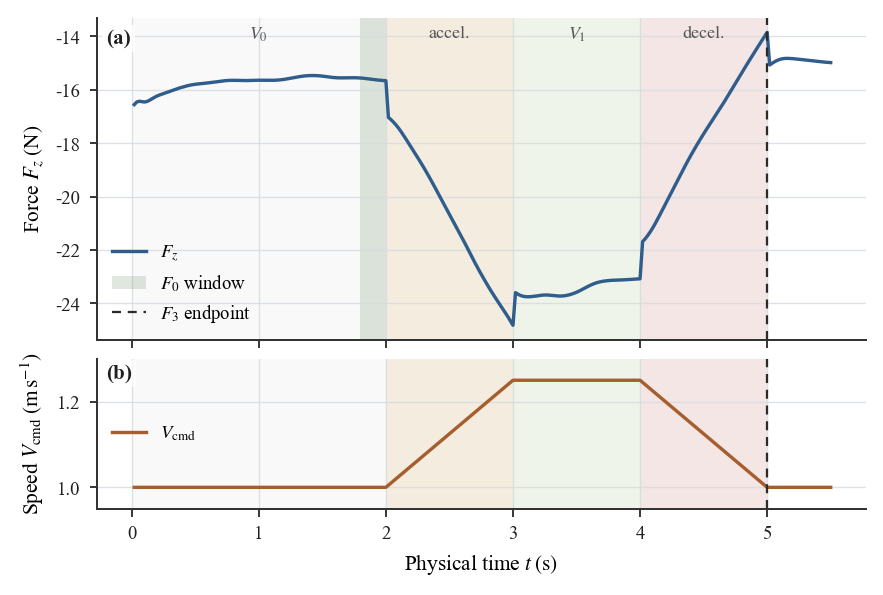

In [3]:
fig, (ax_force, ax_speed) = plt.subplots(
    2,
    1,
    figsize=FIG_FORCE,
    dpi=FIG_DPI,
    sharex=True,
    gridspec_kw={"height_ratios": [2.15, 1.0], "hspace": 0.08},
)

for ax in (ax_force, ax_speed):
    shade_velocity_phases(ax, annotate=(ax is ax_force))
    style_axis(ax)

ax_force.plot(
    force_time["Physical_time_s"],
    force_time[FORCE_COLUMN],
    color=PAPER_COLORS["force"],
    lw=1.35,
    label=rf"${FORCE_COMPONENT}$",
    zorder=3,
)
ax_force.axvspan(
    F0_WINDOW[0],
    F0_WINDOW[1],
    color=PAPER_COLORS["extract"],
    alpha=0.18,
    lw=0,
    label=r"$F_0$ window",
    zorder=1,
)
ax_force.axvline(F3_TIME, color=PAPER_COLORS["marker"], ls=(0, (4, 3)), lw=0.9, label=r"$F_3$ endpoint", zorder=4)
ax_force.set_ylabel(rf"Force ${FORCE_COMPONENT}\;(\mathrm{{N}})$")
ax_force.legend(loc="best", frameon=False, handlelength=1.8, borderaxespad=0.4)
add_panel_label(ax_force, "(a)")

ax_speed.plot(
    force_time["Physical_time_s"],
    force_time["Vcmd_mps"],
    color=PAPER_COLORS["speed"],
    lw=1.35,
    label=r"$V_{\mathrm{cmd}}$",
    zorder=3,
)
ax_speed.axvline(F3_TIME, color=PAPER_COLORS["marker"], ls=(0, (4, 3)), lw=0.9, zorder=4)
ax_speed.set_ylabel(r"Speed $V_{\mathrm{cmd}}\;(\mathrm{m\,s^{-1}})$")
ax_speed.set_xlabel(r"Physical time $t\;(\mathrm{s})$")
ax_speed.set_ylim(0.95, 1.30)
ax_speed.legend(loc="best", frameon=False, handlelength=1.8, borderaxespad=0.4)
add_panel_label(ax_speed, "(b)")

fig.align_ylabels([ax_force, ax_speed])
plt.show()


## 4. 提取 $F_{z,0}$ 和 $F_{z,3}$

推荐做法：

- $F_{z,0}$：取 $t=1.8$--2.0 s 的窗口均值，用于降低微小数值波动；
- $F_{z,3}$：取 $t=5.0$ s 的单点末值，不能取 5.02 s 或之后的恢复段数据。


In [4]:
t = force_time["Physical_time_s"]

f0_mask = (t >= F0_WINDOW[0]) & (t <= F0_WINDOW[1])
f0_df = force_time.loc[f0_mask].copy()
assert len(f0_df) > 0, "F0 窗口内没有数据"

F0 = float(f0_df[FORCE_COLUMN].mean())
F0_STD = float(f0_df[FORCE_COLUMN].std(ddof=0))
F0_N = int(len(f0_df))

f3_candidates = force_time.loc[np.isclose(force_time["Physical_time_s"], F3_TIME, atol=1e-10)].copy()
assert len(f3_candidates) == 1, f"没有唯一的 t={F3_TIME} s 数据点"
f3_row = f3_candidates.iloc[0]
F3 = float(f3_row[FORCE_COLUMN])

extract_table = pd.DataFrame(
    [
        {"item": f"{FORCE_ENDPOINT_0} window", "value": f"{F0_WINDOW[0]}--{F0_WINDOW[1]}", "unit": "s"},
        {"item": f"{FORCE_ENDPOINT_0} mean", "value": F0, "unit": "N"},
        {"item": f"{FORCE_ENDPOINT_0} std", "value": F0_STD, "unit": "N"},
        {"item": f"{FORCE_ENDPOINT_0} samples", "value": F0_N, "unit": "time steps"},
        {"item": f"{FORCE_ENDPOINT_3} time", "value": F3_TIME, "unit": "s"},
        {"item": f"{FORCE_ENDPOINT_3}", "value": F3, "unit": "N"},
        {"item": f"{FORCE_ENDPOINT_3} iteration", "value": int(f3_row["Iteration"]), "unit": "iteration"},
    ]
)
display(extract_table)


,item,value,unit
0,"F_{z,0} window",1.8--2.0,s
1,"F_{z,0} mean",-15.6116,N
2,"F_{z,0} std",0.0339336,N
3,"F_{z,0} samples",11,time steps
4,"F_{z,3} time",5,s
5,"F_{z,3}",-13.8479,N
6,"F_{z,3} iteration",12800,iteration


## 5. 计算 $-Z_{\dot w}$ 和论文中的 $m_z$

先计算：

$$
-Z_{\dot w}
=
\frac{\left|F_{z,3}-F_{z,0}\right|}{\left|a_z\right|}
-
\rho V_d.
$$

再换算：

$$
m_z=m+(-Z_{\dot w}).
$$

如果 `BODY_MASS_KG = None`，本 cell 只输出 $-Z_{\dot w}$。填入刚体质量后，重新运行本 cell 即可得到论文中的 $m_z$。


In [5]:
delta_F = abs(F3 - F0)
apparent_mass = delta_F / ABS_ACCEL
displaced_mass = RHO * V_DISPLACED
minus_Z_dot_w = apparent_mass - displaced_mass

if BODY_MASS_KG is None:
    effective_inertia = np.nan
    effective_inertia_note = "请先填写 BODY_MASS_KG"
else:
    effective_inertia = BODY_MASS_KG + minus_Z_dot_w
    effective_inertia_note = "已计算"

result = pd.DataFrame(
    [
        {"symbol": f"${FORCE_ENDPOINT_0}$", "value": F0, "unit": "N", "meaning": "低速恒速窗口均值"},
        {"symbol": f"${FORCE_ENDPOINT_3}$", "value": F3, "unit": "N", "meaning": "减速段末端力"},
        {"symbol": f"$|{FORCE_ENDPOINT_3}-{FORCE_ENDPOINT_0}|$", "value": delta_F, "unit": "N", "meaning": "同速力差"},
        {"symbol": r"$|a|$", "value": ABS_ACCEL, "unit": "m/s^2", "meaning": "加速度幅值"},
        {"symbol": r"$|\\Delta F|/|a|$", "value": apparent_mass, "unit": "kg", "meaning": "表观加速度质量"},
        {"symbol": r"$\\rho V_d$", "value": displaced_mass, "unit": "kg", "meaning": "排水质量扣除项"},
        {"symbol": f"${ADDED_MASS_SYMBOL}$", "value": minus_Z_dot_w, "unit": "kg", "meaning": "CFD 识别的正 added-mass scalar"},
        {"symbol": f"${EFFECTIVE_INERTIA_SYMBOL}$", "value": effective_inertia, "unit": "kg", "meaning": effective_inertia_note},
    ]
)

display(result)
result.to_csv(DATA_DIR / RESULT_FILE, index=False, encoding="utf-8-sig")
print(f"Saved: {DATA_DIR / RESULT_FILE}")


,symbol,value,unit,meaning
0,"$F_{z,0}$",-15.6116,N,低速恒速窗口均值
1,"$F_{z,3}$",-13.8479,N,减速段末端力
2,"$|F_{z,3}-F_{z,0}|$",1.76369,N,同速力差
3,$|a|$,0.25,m/s^2,加速度幅值
4,$|\\Delta F|/|a|$,7.05477,kg,表观加速度质量
5,$\\rho V_d$,2.56972,kg,排水质量扣除项
6,$-Z_{\dot w}$,4.48505,kg,CFD 识别的正 added-mass scalar
7,$m_z$,7.03505,kg,已计算


Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\mz_data\mz_result_summary.csv


## 6. 端点窗口敏感性诊断

这一表用于检查 $F_0$ 的取值是否对低速稳态窗口过度敏感。主结果仍采用第 4--5 节中定义的 `F0_WINDOW` 和 `F3_TIME`；这里仅改变 $F_0$ 的提取方式，并保持 $F_3$ 固定为减速段末端 $t=5.0\,\mathrm{s}$。

如果合理窗口内的 added-mass scalar 相对变化较小，说明端点选择不是主要不确定性来源。


In [6]:
# DIAGNOSTIC_ENDPOINT_SENSITIVITY
F0_WINDOWS = [
    (1.60, 2.00),
    (1.70, 2.00),
    (1.80, 2.00),
    (1.90, 2.00),
]

baseline_added_mass = apparent_mass - displaced_mass
endpoint_rows = []

for start, end in F0_WINDOWS:
    mask = (force_time["Physical_time_s"] >= start) & (force_time["Physical_time_s"] <= end)
    window_df = force_time.loc[mask].copy()
    assert len(window_df) > 0, f"No data in F0 window {start}--{end}"

    f0_mean = float(window_df[FORCE_COLUMN].mean())
    f0_std = float(window_df[FORCE_COLUMN].std(ddof=0))
    delta_f = abs(F3 - f0_mean)
    mass_scalar = delta_f / ABS_ACCEL - displaced_mass
    label = f"{start:.2f}--{end:.2f}"
    if np.isclose(start, F0_WINDOW[0]) and np.isclose(end, F0_WINDOW[1]):
        label += " (baseline)"

    endpoint_rows.append(
        {
            "F0_source": label,
            "F0_samples": int(len(window_df)),
            "F0_mean_N": f0_mean,
            "F0_std_N": f0_std,
            "F3_time_s": F3_TIME,
            "F3_N": F3,
            "added_mass_scalar_kg": mass_scalar,
        }
    )

f0_single = force_time.iloc[(force_time["Physical_time_s"] - F3_TIME + 3.0).abs().argmin()]
f0_single_time = float(f0_single["Physical_time_s"])
f0_single_value = float(f0_single[FORCE_COLUMN])
single_delta_f = abs(F3 - f0_single_value)
single_mass_scalar = single_delta_f / ABS_ACCEL - displaced_mass
endpoint_rows.append(
    {
        "F0_source": f"single t={f0_single_time:.2f}",
        "F0_samples": 1,
        "F0_mean_N": f0_single_value,
        "F0_std_N": 0.0,
        "F3_time_s": F3_TIME,
        "F3_N": F3,
        "added_mass_scalar_kg": single_mass_scalar,
    }
)

endpoint_sensitivity = pd.DataFrame(endpoint_rows)
if abs(baseline_added_mass) > 1e-12:
    endpoint_sensitivity["relative_change_percent"] = (
        (endpoint_sensitivity["added_mass_scalar_kg"] - baseline_added_mass)
        / abs(baseline_added_mass)
        * 100.0
    )
else:
    endpoint_sensitivity["relative_change_percent"] = np.nan

display(endpoint_sensitivity)
endpoint_path = DATA_DIR / f"{CASE_NAME}_endpoint_sensitivity.csv"
endpoint_sensitivity.to_csv(endpoint_path, index=False, encoding="utf-8-sig")
print(f"Saved: {endpoint_path}")


,F0_source,F0_samples,F0_mean_N,F0_std_N,F3_time_s,F3_N,added_mass_scalar_kg,relative_change_percent
0,1.60--2.00,21,-15.5829,0.0388996,5,-13.8479,4.37018,-2.56114
1,1.70--2.00,16,-15.5924,0.0400025,5,-13.8479,4.4084,-1.70895
2,1.80--2.00 (baseline),11,-15.6116,0.0339336,5,-13.8479,4.48505,0
3,1.90--2.00,6,-15.6392,0.0153491,5,-13.8479,4.59556,2.46388
4,single t=2.00,1,-15.6585,0,5,-13.8479,4.67264,4.18262


Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\mz_data\mz_endpoint_sensitivity.csv


## 7. 残差诊断

残差不直接进入有效惯性公式，但它决定关键力末值是否可信。

重点检查：

1. 每个时间步末端是否达到可接受收敛；
2. $t=2.0\,\mathrm{s}$ 和 $t=5.0\,\mathrm{s}$ 两个提取点是否没有明显数值异常；
3. 加速/减速段内残差阶跃是正常现象，但每个时间步末端应能回落。


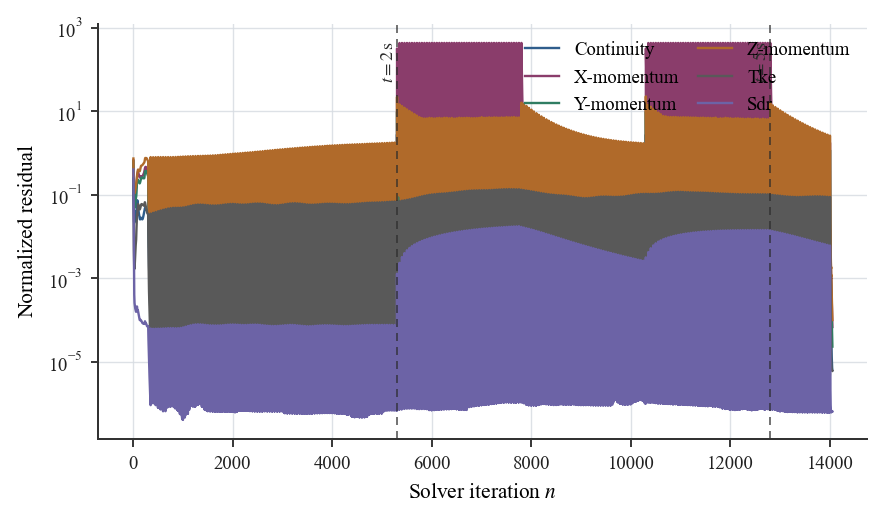

,TimeStep,Physical_time_s,Iteration,Continuity,X_momentum,Y_momentum,Z_momentum,Tke,Sdr,Fz_body_N,wall_Yplus
5296,100,2,5300,8.06678e-06,0.000132839,1.91478e-05,7.91373e-05,1.43251e-05,6.88893e-07,-15.6585,NaN
12796,250,5,12800,0.00027905,0.032083,0.00161492,0.00617524,3.48254e-06,7.12097e-07,-13.8479,6.39042


In [7]:
res_cols = ["Continuity", "X_momentum", "Y_momentum", "Z_momentum", "Tke", "Sdr"]

final_rows = residuals.dropna(subset=["Physical_time_s"]).copy()
check_times = [2.0, 5.0]
check_rows = []
extraction_iterations = []
for check_t in check_times:
    row = final_rows.iloc[(final_rows["Physical_time_s"] - check_t).abs().argmin()]
    extraction_iterations.append((float(row["Iteration"]), check_t))
    cols = [
        "TimeStep",
        "Physical_time_s",
        "Iteration",
        "Continuity",
        "X_momentum",
        "Y_momentum",
        "Z_momentum",
        "Tke",
        "Sdr",
        FORCE_COLUMN,
    ]
    if "wall_Yplus" in final_rows.columns:
        cols.append("wall_Yplus")
    check_rows.append(row[cols])

fig, ax = plt.subplots(figsize=FIG_RESIDUAL, dpi=FIG_DPI)
for color, col in zip(RESIDUAL_COLORS, res_cols):
    ax.semilogy(residuals["Iteration"], residuals[col], lw=0.95, color=color, label=col.replace("_", "-"))

for iteration, check_t in extraction_iterations:
    ax.axvline(iteration, color=PAPER_COLORS["marker"], ls=(0, (4, 3)), lw=0.8, alpha=0.65)
    ax.text(
        iteration,
        0.96,
        rf"$t={check_t:.0f}\,\mathrm{{s}}$",
        transform=ax.get_xaxis_transform(),
        ha="right",
        va="top",
        rotation=90,
        fontsize=7.2,
        color=PAPER_COLORS["marker"],
    )

style_axis(ax, grid="both")
ax.set_xlabel(r"Solver iteration $n$")
ax.set_ylabel(r"Normalized residual")
ax.legend(ncol=2, frameon=False, loc="upper right", handlelength=1.8, columnspacing=1.0)
plt.show()

display(pd.DataFrame(check_rows))


## 8. 关键时间步末端内迭代收敛表

这一表检查 $t=2.0\,\mathrm{s}$ 和 $t=5.0\,\mathrm{s}$ 所在时间步的最后若干次内迭代。相对单看 residual，这个表更直接回答：用于计算 $F_0$ 和 $F_3$ 的力值在时间步末端是否已经稳定。

默认统计每个关键时间步最后 10 次内迭代的力均值、标准差和范围。


In [8]:
# DIAGNOSTIC_INNER_ITERATION_CONVERGENCE
FINAL_ITERATION_WINDOW = 10
KEY_TIMES = [F0_WINDOW[1], F3_TIME]

residuals_numeric = residuals.copy()
numeric_cols = [
    "Iteration",
    "TimeStep",
    "Physical_time_s",
    "Continuity",
    "X_momentum",
    "Y_momentum",
    "Z_momentum",
    "Tke",
    "Sdr",
    FORCE_COLUMN,
]
if "wall_Yplus" in residuals_numeric.columns:
    numeric_cols.append("wall_Yplus")

for col in numeric_cols:
    if col in residuals_numeric.columns:
        residuals_numeric[col] = pd.to_numeric(residuals_numeric[col], errors="coerce")

final_rows = residuals_numeric.dropna(subset=["Physical_time_s"]).copy()
inner_rows = []

for target_time in KEY_TIMES:
    final_row = final_rows.iloc[(final_rows["Physical_time_s"] - target_time).abs().argmin()]
    final_iter = int(final_row["Iteration"])
    iter_window = residuals_numeric.loc[
        (residuals_numeric["Iteration"] >= final_iter - FINAL_ITERATION_WINDOW + 1)
        & (residuals_numeric["Iteration"] <= final_iter)
    ].copy()
    assert len(iter_window) > 0, f"No inner-iteration rows found for t={target_time}"

    force_series = iter_window[FORCE_COLUMN].astype(float)
    force_last = float(final_row[FORCE_COLUMN])
    denom = max(abs(force_last), 1e-12)

    row = {
        "target_time_s": target_time,
        "actual_time_s": float(final_row["Physical_time_s"]),
        "TimeStep": int(final_row["TimeStep"]),
        "final_iteration": final_iter,
        "n_last_inner_iterations": int(len(iter_window)),
        "force_last_N": force_last,
        "force_mean_last10_N": float(force_series.mean()),
        "force_std_last10_N": float(force_series.std(ddof=0)),
        "force_range_last10_N": float(force_series.max() - force_series.min()),
        "force_rel_std_percent": float(force_series.std(ddof=0) / denom * 100.0),
        "force_rel_range_percent": float((force_series.max() - force_series.min()) / denom * 100.0),
        "Continuity_final": float(final_row["Continuity"]),
        "X_momentum_final": float(final_row["X_momentum"]),
        "Y_momentum_final": float(final_row["Y_momentum"]),
        "Z_momentum_final": float(final_row["Z_momentum"]),
        "Tke_final": float(final_row["Tke"]),
        "Sdr_final": float(final_row["Sdr"]),
    }
    if "wall_Yplus" in final_row.index and pd.notna(final_row["wall_Yplus"]):
        row["wall_Yplus_final"] = float(final_row["wall_Yplus"])
    inner_rows.append(row)

inner_iteration_convergence = pd.DataFrame(inner_rows)
display(inner_iteration_convergence)
inner_path = DATA_DIR / f"{CASE_NAME}_inner_iteration_convergence.csv"
inner_iteration_convergence.to_csv(inner_path, index=False, encoding="utf-8-sig")
print(f"Saved: {inner_path}")


,target_time_s,actual_time_s,TimeStep,final_iteration,n_last_inner_iterations,force_last_N,force_mean_last10_N,force_std_last10_N,force_range_last10_N,force_rel_std_percent,force_rel_range_percent,Continuity_final,X_momentum_final,Y_momentum_final,Z_momentum_final,Tke_final,Sdr_final,wall_Yplus_final
0,2,2,100,5300,10,-15.6585,-15.6584,3.44238e-05,0.00011,0.000219842,0.000702495,8.06678e-06,0.000132839,1.91478e-05,7.91373e-05,1.43251e-05,6.88893e-07,NaN
1,5,5,250,12800,10,-13.8479,-13.848,3.88458e-05,0.00012,0.000280518,0.000866559,0.00027905,0.032083,0.00161492,0.00617524,3.48254e-06,7.12097e-07,6.39042


Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\mz_data\mz_inner_iteration_convergence.csv


## 9. 当前结果的专业判断

这个 notebook 给出的是 forced-acceleration CFD 的后处理结果，不应把它和稳态 AoA 图谱混在一起解释。

- $F_{z,0}$ 采用 1.8--2.0 s 窗口均值；
- $F_{z,3}$ 取 5.0 s，正好是减速段末端，不能取 5.02 s 或后续恢复段；
- $-Z_{\dot w}$ 是 CFD 识别的正 added-mass scalar；
- 论文中的 $m_z$ 应通过 $m_z=m+(-Z_{\dot w})$ 得到；
- 当前量级判断：需要结合计算结果和结构开口特征判断。最终是否能写入论文，还应结合时间序列图、端点残差、网格/时间步敏感性和重复加速度幅值检查。

论文写作时建议表述为：

> The forced-acceleration CFD test identifies the positive translational added-mass scalar. The effective inertia used in the reduced-order equation is then obtained by adding this scalar to the rigid-body mass.
